# Multiclass
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [122]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [123]:
df = pd.read_csv('/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/src/data/checker_submits.csv')

In [124]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df.drop(['timestamp'], axis=1)
display(df)

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [125]:
encoder = OneHotEncoder(sparse_output=False)
categorical_features = ['uid', 'labname']
encoded_data = encoder.fit_transform(df[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
df.drop(columns=categorical_features, inplace=True)
df = pd.concat([df.reset_index(drop=True), encoded_df], axis=1)
display(df)



,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,9,20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,6,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,7,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,8,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [126]:
scaler = StandardScaler()
numerical_features = ['numTrials', 'hour']
scaled_numericals = scaler.fit_transform(df[numerical_features])
df[numerical_features] = scaled_numericals
display(df)


,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [127]:
df.to_csv('/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/src/data/dayofweek.csv', index=False)

In [128]:
x = df.drop(['dayofweek'], axis=1)
y = df['dayofweek'] 

most_common_class = df['dayofweek'].mode()[0]
predictions = [most_common_class]*len(df)
accuracy = sum(predictions == df['dayofweek']) / len(df)
print(f"Naive precision: {accuracy:.4f}")

Naive precision: 0.2349


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [129]:
logreg = LogisticRegression( solver="lbfgs", random_state=21, fit_intercept=False)
logreg.fit(x, y)
y_pred = logreg.predict(x)
accuracy = accuracy_score(y, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6406


The best sign: uid_user_14 with an importance coefficient: 9.7552


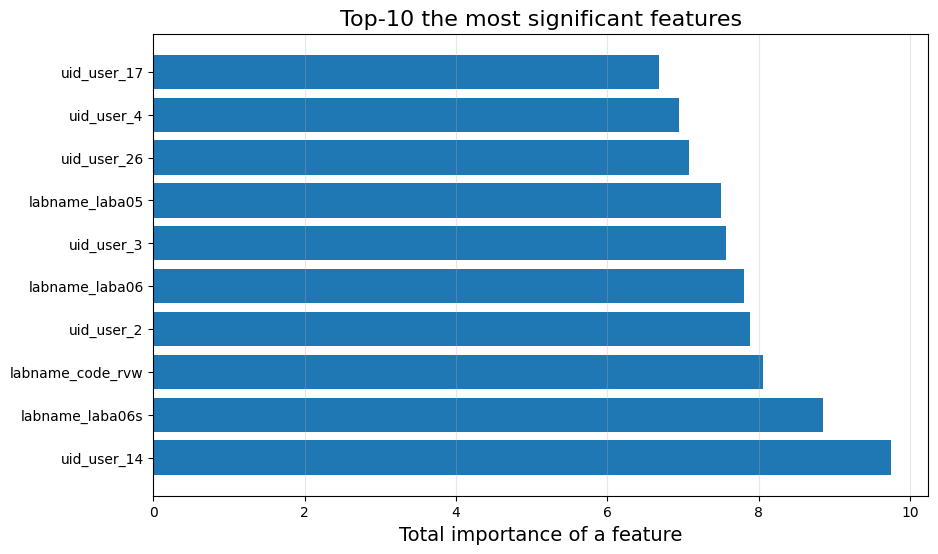

In [130]:
def plot_feature_importance(coefficients, feature_names, n_top_features):
    abs_coefficients = np.abs(coefficients).sum(axis=0)
    sorted_indices = np.argsort(abs_coefficients)[::-1]
    top_n_indices = sorted_indices[:n_top_features]
    top_n_features = [feature_names[i] for i in top_n_indices]
    top_n_coefficients = abs_coefficients[top_n_indices]

    print(f"The best sign: {top_n_features[0]} with an importance coefficient: {top_n_coefficients[0]:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_n_features, top_n_coefficients)
    plt.xlabel('Total importance of a feature', fontsize=14)
    plt.ylabel('')
    plt.title(f"Top-{n_top_features} the most significant features", fontsize=16)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

feature_names = list(x.columns)
coefficients_a = logreg.coef_

plot_feature_importance(coefficients_a, feature_names, 10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [131]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svc_model = SVC(kernel=kernel, probability=True, random_state=21)
    svc_model.fit(x, y)
    y_pred = svc_model.predict(x)
    accuracy = accuracy_score(y, y_pred)
    print(f'Accuracy kernel {kernel}: {accuracy:.4f}')

Accuracy kernel linear: 0.7028
Accuracy kernel poly: 0.8594
Accuracy kernel rbf: 0.8559
Accuracy kernel sigmoid: 0.3998


The best sign: uid_user_2 with an importance coefficient: 6.0022


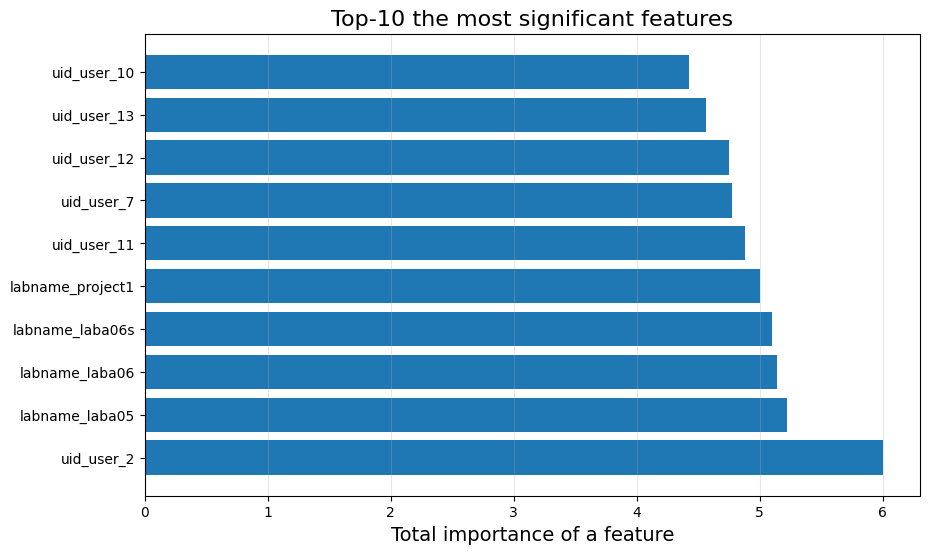

In [132]:
ovr_clf = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21)).fit(x, y)
coefficients_b = np.concatenate([clf.coef_ for clf in ovr_clf.estimators_])

plot_feature_importance(coefficients_b, feature_names, 10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [133]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 15]

for depth in depths:
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=21)
    dtc.fit(x, y)
    y_pred = dtc.predict(x)
    accuracy = accuracy_score(y, y_pred)
    print(f'Depth: {depth}, Accuracy: {accuracy:.4f}')

Depth: 2, Accuracy: 0.4389
Depth: 3, Accuracy: 0.4899
Depth: 4, Accuracy: 0.5516
Depth: 5, Accuracy: 0.6109
Depth: 6, Accuracy: 0.6637
Depth: 8, Accuracy: 0.7503
Depth: 10, Accuracy: 0.8197
Depth: 12, Accuracy: 0.8832
Depth: 15, Accuracy: 0.9460


The best sign: labname_project1 with an importance coefficient: 0.2746


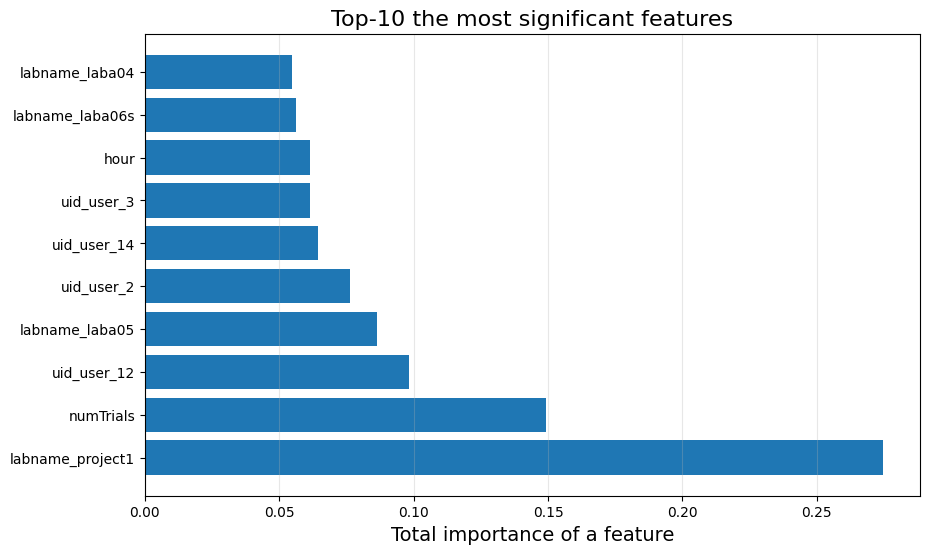

In [134]:
baseline_dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
baseline_dtc.fit(x, y)
coefficients_c = np.expand_dims(baseline_dtc.feature_importances_, axis=0)

plot_feature_importance(coefficients_c, feature_names, 10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [135]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rfc.fit(x, y)
y_pred = rfc.predict(x)
accuracy = accuracy_score(y, y_pred)
print(f'Accuracy: {accuracy:.7f}')

Accuracy: 1.0000000


In [136]:
depths = [10, 20, 25]
estimators = [50, 100, 200]
results = []

for depth in depths:
    for est in estimators:
        models = RandomForestClassifier(
            n_estimators=est,
            max_depth=depth,
            random_state=21
        )
        models.fit(x, y)
        y_pred = models.predict(x)
        acc = accuracy_score(y, y_pred)
        results.append((depth, est, acc))
for result in results:
    print(f'Depth={result[0]}, Estimators={result[1]} => Accuracy: {result[2]:.4f}')

Depth=10, Estimators=50 => Accuracy: 0.8701
Depth=10, Estimators=100 => Accuracy: 0.8855
Depth=10, Estimators=200 => Accuracy: 0.8778
Depth=20, Estimators=50 => Accuracy: 0.9970
Depth=20, Estimators=100 => Accuracy: 0.9964
Depth=20, Estimators=200 => Accuracy: 0.9964
Depth=25, Estimators=50 => Accuracy: 1.0000
Depth=25, Estimators=100 => Accuracy: 1.0000
Depth=25, Estimators=200 => Accuracy: 1.0000


The best sign: numTrials with an importance coefficient: 0.2851


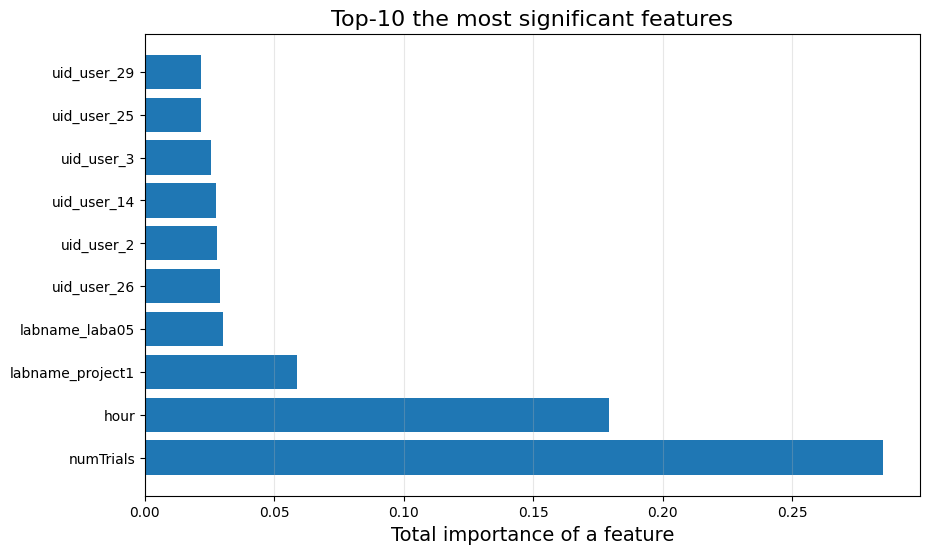

In [138]:
coefficients_d = np.expand_dims(rfc.feature_importances_, axis=0)
plot_feature_importance(coefficients_d, feature_names, 10)